### inspecting the thresholds

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
from scipy.stats import spearmanr

In [2]:
DIR_3B = "results_fairness_over_time"
DIR_6_8B = "results_fairness_over_time_6to8b"
DIR_27_34B = "results_fairness_over_time_27to34b"

In [3]:
def load_summary_folder(out_dir, size_group):
    path = os.path.join(out_dir, "summary_all_models.csv")
    df = pd.read_csv(path).sort_values(["year", "model_id"]).reset_index(drop=True)
    df["size_group"] = size_group
    return df

In [4]:
df_3b = load_summary_folder(DIR_3B, "3B")
df_6_8b = load_summary_folder(DIR_6_8B, "6-8B")
df_27_34b = load_summary_folder(DIR_27_34B, "27-34B")

df_all = pd.concat([df_3b, df_6_8b, df_27_34b], ignore_index=True)

BAD_MODEL_IDS = {
    "stabilityai/stablelm-base-alpha-7b-v2",
    "tiiuae/Falcon-H1-34B-Base",
}

df_all = df_all[~df_all["model_id"].isin(BAD_MODEL_IDS)].copy().reset_index(drop=True)

cols = [
    "year", "model_id", "size_group",
    "base_rate_cal", "threshold_t",
    "test_acc", "test_pos_rate", "test_fpr", "test_fnr"
]
df_thr = df_all[cols].copy()

df_thr.head()

,year,model_id,size_group,base_rate_cal,threshold_t,test_acc,test_pos_rate,test_fpr,test_fnr
0,2021,EleutherAI/gpt-neo-2.7B,3B,0.115,0.862521,0.792,0.103,0.108077,0.933884
1,2021,facebook/xglm-2.9B,3B,0.115,0.651355,0.776,0.131,0.133106,0.884298
2,2022,EleutherAI/pythia-2.8b-deduped-v0,3B,0.115,0.403567,0.808,0.091,0.092150,0.917355
3,2022,EleutherAI/pythia-2.8b-v0,3B,0.115,0.724870,0.806,0.111,0.104664,0.842975
4,2022,Salesforce/codegen-2B-multi,3B,0.115,0.675765,0.770,0.149,0.146758,0.834711


In [5]:
# descriptive summary
df_thr[[
    "threshold_t", "test_acc", "test_pos_rate", "test_fpr", "test_fnr"
]].describe().round(4)

,threshold_t,test_acc,test_pos_rate,test_fpr,test_fnr
count,54.0000,54.0000,54.0000,54.0000,54.0000
mean,0.6347,0.8086,0.1128,0.1042,0.8249
std,0.1491,0.0179,0.0146,0.0155,0.0745
min,0.3226,0.7700,0.0850,0.0728,0.6612
25%,0.5437,0.7972,0.1022,0.0913,0.7810
50%,0.6352,0.8080,0.1125,0.1035,0.8347
75%,0.7217,0.8205,0.1208,0.1126,0.8843
max,0.9855,0.8460,0.1490,0.1468,0.9421


In [6]:
# models sorted by threshold
df_thr.sort_values("threshold_t")[
    ["year", "model_id", "size_group", "threshold_t", "test_acc", "test_pos_rate", "test_fpr", "test_fnr"]
].round(4)

,year,model_id,size_group,threshold_t,test_acc,test_pos_rate,test_fpr,test_fnr
6,2022,bigscience/bloomz-3b,3B,0.3226,0.819,0.110,0.0967,0.7934
42,2024,allenai/OLMo-7B-0424-hf,6-8B,0.3451,0.816,0.111,0.0990,0.8017
38,2023,openlm-research/open_llama_7b,6-8B,0.3788,0.800,0.103,0.1035,0.9008
2,2022,EleutherAI/pythia-2.8b-deduped-v0,3B,0.4036,0.808,0.091,0.0922,0.9174
31,2022,EleutherAI/pythia-6.9b-v0,6-8B,0.4321,0.798,0.101,0.1035,0.9174
11,2023,openlm-research/open_llama_3b,3B,0.4451,0.809,0.106,0.1001,0.8512
24,2024,state-spaces/mamba-2.8b-hf,3B,0.4533,0.813,0.094,0.0910,0.8843
47,2025,Qwen/Qwen3-8B-Base,6-8B,0.4533,0.831,0.122,0.0967,0.6942
35,2023,EleutherAI/pythia-6.9b-deduped,6-8B,0.5039,0.821,0.098,0.0887,0.8347
37,2023,mistralai/Mistral-7B-v0.1,6-8B,0.5137,0.796,0.121,0.1160,0.8430


In [7]:
# highest thresholds
df_thr.sort_values("threshold_t", ascending=False)[
    ["year", "model_id", "size_group", "threshold_t", "test_acc", "test_pos_rate", "test_fpr", "test_fnr"]
].round(4)

,year,model_id,size_group,threshold_t,test_acc,test_pos_rate,test_fpr,test_fnr
48,2025,ibm-granite/granite-3.1-8b-base,6-8B,0.9855,0.808,0.127,0.1126,0.7686
28,2025,tiiuae/Falcon-H1-3B-Base,3B,0.9119,0.846,0.095,0.0728,0.7438
9,2023,cerebras/Cerebras-GPT-2.7B,3B,0.8757,0.775,0.140,0.1388,0.8512
0,2021,EleutherAI/gpt-neo-2.7B,3B,0.8625,0.792,0.103,0.1081,0.9339
50,2023,01-ai/Yi-34B,27-34B,0.8587,0.836,0.107,0.0853,0.7355
25,2024,tiiuae/Falcon3-3B-Base,3B,0.8578,0.827,0.098,0.0853,0.8099
10,2023,microsoft/phi-2,3B,0.8470,0.832,0.095,0.0808,0.8017
5,2022,bigscience/bloom-3b,3B,0.8210,0.799,0.094,0.0990,0.9421
21,2024,nvidia/Minitron-4B-Base,3B,0.8081,0.830,0.105,0.0876,0.7686
36,2023,meta-llama/Llama-2-7b-hf,6-8B,0.7787,0.810,0.113,0.1035,0.8182


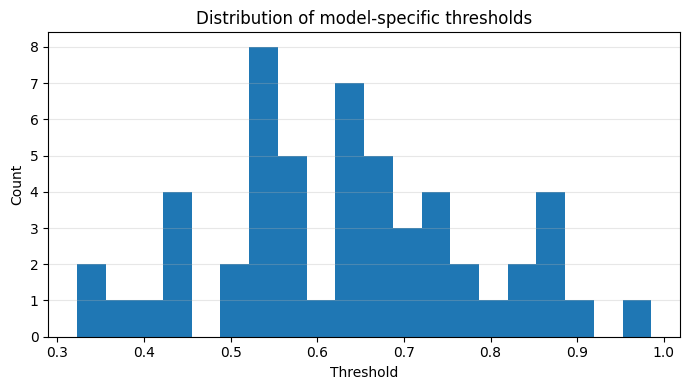

In [8]:
# histogram of thresholds
plt.figure(figsize=(7, 4))
plt.hist(df_thr["threshold_t"].dropna(), bins=20)
plt.xlabel("Threshold")
plt.ylabel("Count")
plt.title("Distribution of model-specific thresholds")
plt.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

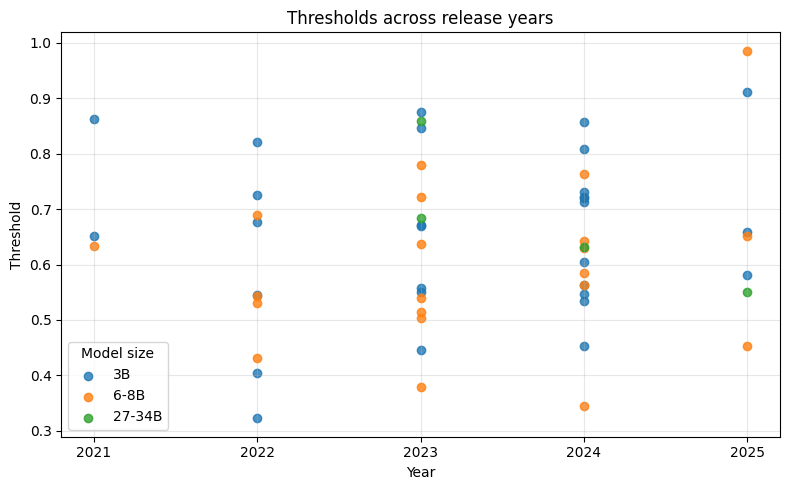

In [9]:
# threshold by year
plt.figure(figsize=(8, 5))
for size_group, sub in df_thr.groupby("size_group", sort=False):
    plt.scatter(sub["year"], sub["threshold_t"], label=size_group, alpha=0.8)

plt.xlabel("Year")
plt.ylabel("Threshold")
plt.title("Thresholds across release years")
plt.gca().xaxis.set_major_locator(MaxNLocator(integer=True))
plt.grid(True, alpha=0.3)
plt.legend(title="Model size")
plt.tight_layout()
plt.show()

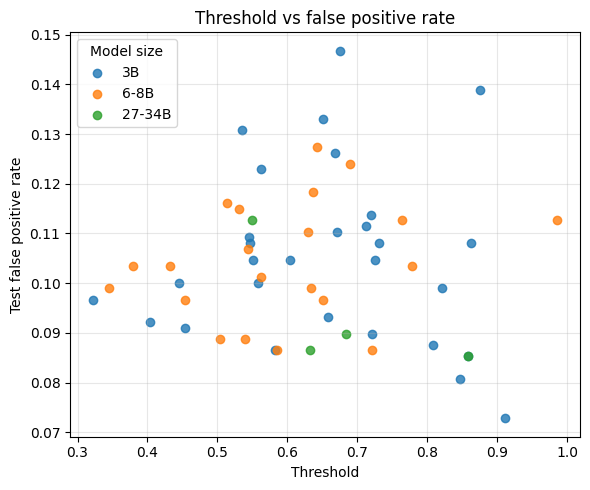

In [10]:
# threshold vs false positive rate
plt.figure(figsize=(6, 5))
for size_group, sub in df_thr.groupby("size_group", sort=False):
    plt.scatter(sub["threshold_t"], sub["test_fpr"], label=size_group, alpha=0.8)

plt.xlabel("Threshold")
plt.ylabel("Test false positive rate")
plt.title("Threshold vs false positive rate")
plt.grid(True, alpha=0.3)
plt.legend(title="Model size")
plt.tight_layout()
plt.show()

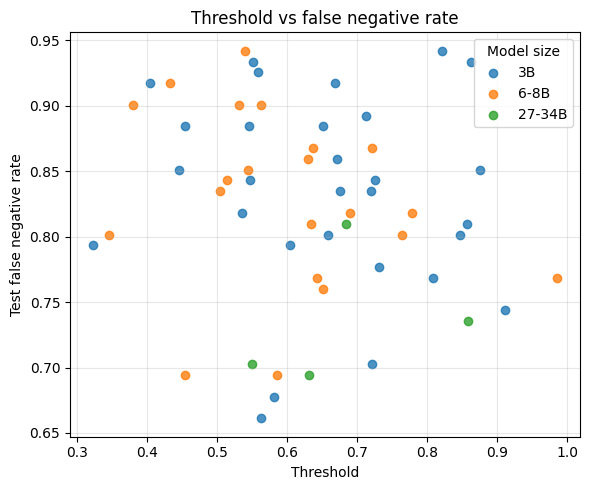

In [11]:
# threshold vs false negative rate
plt.figure(figsize=(6, 5))
for size_group, sub in df_thr.groupby("size_group", sort=False):
    plt.scatter(sub["threshold_t"], sub["test_fnr"], label=size_group, alpha=0.8)

plt.xlabel("Threshold")
plt.ylabel("Test false negative rate")
plt.title("Threshold vs false negative rate")
plt.grid(True, alpha=0.3)
plt.legend(title="Model size")
plt.tight_layout()
plt.show()

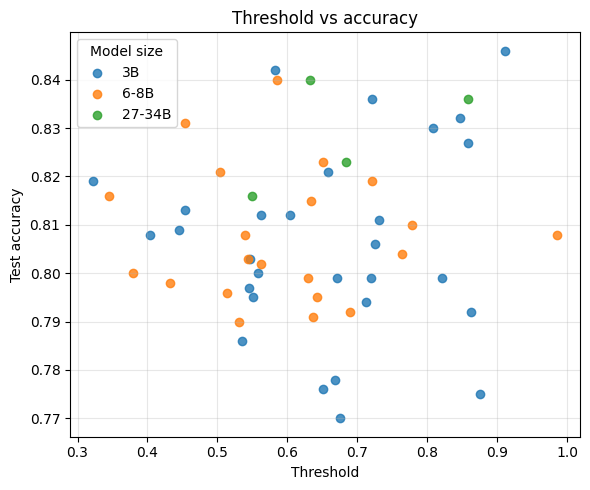

In [12]:
# threshold vs accuracy
plt.figure(figsize=(6, 5))
for size_group, sub in df_thr.groupby("size_group", sort=False):
    plt.scatter(sub["threshold_t"], sub["test_acc"], label=size_group, alpha=0.8)

plt.xlabel("Threshold")
plt.ylabel("Test accuracy")
plt.title("Threshold vs accuracy")
plt.grid(True, alpha=0.3)
plt.legend(title="Model size")
plt.tight_layout()
plt.show()

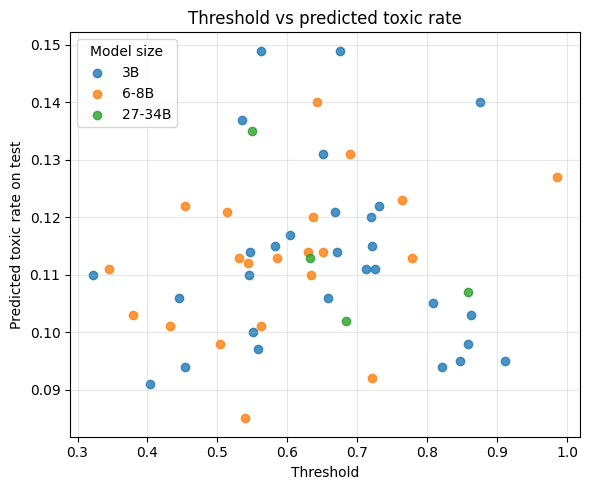

In [13]:
# threshold vs predicted toxic rate
plt.figure(figsize=(6, 5))
for size_group, sub in df_thr.groupby("size_group", sort=False):
    plt.scatter(sub["threshold_t"], sub["test_pos_rate"], label=size_group, alpha=0.8)

plt.xlabel("Threshold")
plt.ylabel("Predicted toxic rate on test")
plt.title("Threshold vs predicted toxic rate")
plt.grid(True, alpha=0.3)
plt.legend(title="Model size")
plt.tight_layout()
plt.show()

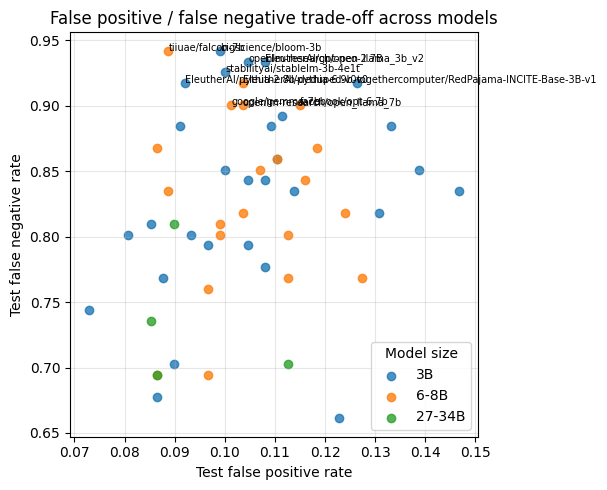

In [14]:
# false positive/false negativve trade-off
plt.figure(figsize=(6, 5))
for size_group, sub in df_thr.groupby("size_group", sort=False):
    plt.scatter(sub["test_fpr"], sub["test_fnr"], label=size_group, alpha=0.8)

for _, row in df_thr.iterrows():
    if row["test_acc"] > 0.87 or row["test_fnr"] > 0.9 or row["test_fpr"] > 0.3:
        plt.text(row["test_fpr"], row["test_fnr"], row["model_id"], fontsize=7)

plt.xlabel("Test false positive rate")
plt.ylabel("Test false negative rate")
plt.title("False positive / false negative trade-off across models")
plt.grid(True, alpha=0.3)
plt.legend(title="Model size")
plt.tight_layout()
plt.show()

In [15]:
# correlation table
def spearman_pair(df, x, y):
    sub = df[[x, y]].dropna()
    if len(sub) < 2:
        return {"x": x, "y": y, "rho": np.nan, "p": np.nan}
    rho, p = spearmanr(sub[x], sub[y])
    return {"x": x, "y": y, "rho": rho, "p": p}

pairs = [
    ("threshold_t", "test_acc"),
    ("threshold_t", "test_pos_rate"),
    ("threshold_t", "test_fpr"),
    ("threshold_t", "test_fnr"),
]

corr_tbl = pd.DataFrame([spearman_pair(df_thr, x, y) for x, y in pairs])
corr_tbl.round(4)

,x,y,rho,p
0,threshold_t,test_acc,0.0696,0.6172
1,threshold_t,test_pos_rate,0.1020,0.4630
2,threshold_t,test_fpr,-0.0236,0.8656
3,threshold_t,test_fnr,-0.1974,0.1525


In [16]:
# suspicious models
suspects = df_thr[
    (df_thr["test_acc"] >= 0.87) |
    (df_thr["test_fnr"] >= 0.90) |
    (df_thr["test_pos_rate"] <= 0.01) |
    (df_thr["test_pos_rate"] >= 0.50)
].copy()

suspects.sort_values(["test_acc", "test_fnr"], ascending=[False, False])[
    ["year", "model_id", "size_group", "threshold_t", "test_acc", "test_pos_rate", "test_fpr", "test_fnr"]
].round(4)

,year,model_id,size_group,threshold_t,test_acc,test_pos_rate,test_fpr,test_fnr
40,2023,tiiuae/falcon-7b,6-8B,0.5390,0.808,0.085,0.0887,0.9421
2,2022,EleutherAI/pythia-2.8b-deduped-v0,3B,0.4036,0.808,0.091,0.0922,0.9174
44,2024,google/gemma-7b,6-8B,0.5622,0.802,0.101,0.1013,0.9008
13,2023,stabilityai/stablelm-3b-4e1t,3B,0.5585,0.800,0.097,0.1001,0.9256
38,2023,openlm-research/open_llama_7b,6-8B,0.3788,0.800,0.103,0.1035,0.9008
5,2022,bigscience/bloom-3b,3B,0.8210,0.799,0.094,0.0990,0.9421
31,2022,EleutherAI/pythia-6.9b-v0,6-8B,0.4321,0.798,0.101,0.1035,0.9174
12,2023,openlm-research/open_llama_3b_v2,3B,0.5506,0.795,0.100,0.1047,0.9339
0,2021,EleutherAI/gpt-neo-2.7B,3B,0.8625,0.792,0.103,0.1081,0.9339
33,2022,facebook/opt-6.7b,6-8B,0.5314,0.790,0.113,0.1149,0.9008
